### 1. 패키지 설치

In [3]:
%pip install -qU langgraph

Note: you may need to restart the kernel to use updated packages.


### 2. 랭그래프 기본 구현법

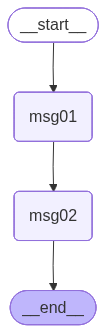

In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class State(TypedDict):
    message: str

def get_msg_01(state: State):   # 노드 함수는 현재 state를 인자로 받아야 함 (없으면 invoke 시 TypeError)
    print('get_msg_01 함수 실행')
    return {'message': 'get_msg_01'}

def get_msg_02(state: State):
    print('get_msg_02 함수 실행')
    return {'message': 'get_msg_02'}

graph = StateGraph(State)

graph.add_node('msg01', get_msg_01)
graph.add_node('msg02', get_msg_02)

graph.add_edge(START, 'msg01')
graph.add_edge('msg01', 'msg02')
graph.add_edge('msg02', END) # END는 기본적으로 작성하지 않아도 동작되지만 적어주는 것이 좋음

app = graph.compile()

app

### 3. 실행 (invoke)
- 시작 state를 넣으면 `msg01 → msg02` 순서로 노드가 실행됨
- 두 노드가 같은 키(`message`)를 반환 → 마지막 노드 값으로 덮어써짐 (누적하려면 reducer 필요)

In [7]:
app.invoke({'message': 'start'})

get_msg_01 함수 실행
get_msg_02 함수 실행


{'message': 'get_msg_02'}